
<a href="https://colab.research.google.com/github/kokchun/Machine-learning-AI22/blob/main/Exercises/E04_logistic_regression.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

---
# Logistic regression exercises 

---
These are introductory exercises in Machine learning with focus in **logistic regression**

<p class = "alert alert-info" role="alert"><b>Note</b> that sometimes you don't get exactly the same answer as I get, but it doesn't neccessarily mean it is wrong. Could be some parameters, randomization, that we have different. Also very important is that in the future there won't be any answer sheets, use your skills in data analysis, mathematics and statistics to back up your work.</p>

<p class = "alert alert-info" role="alert"><b>Note</b> that in cases when you start to repeat code, try not to. Create functions to reuse code instead. </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable, function, index </b> and <b> column names</b> in order to get readable code </p>

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

## 0. Iris flower dataset (*)

In the whole exercise, we will work with the famous Iris flower dataset, which was collected in 1936 by Ronald Fisher, a statistician and biologist. Use the ```datasets``` module from scikit-learn to load the iris dataset. 

&nbsp; a) Check keys on the loaded data and check what the different values for each key are.

&nbsp; b) Now insert the data into a DataFrame. 

&nbsp; c) Do some EDA to get an understanding of the dataset. 

&nbsp; d) Make a correlation heatmap to see how each feature is correlated to each other. What do the numbers mean?

&nbsp; e) Make a boxplot. The points outside of the boxplot are statistically calculated outliers using Tukey's rule for boxplot. 

&nbsp; f) Now remove the outliers in data. (**)

- Lower bound outlier: $Q_1 - 1.5\cdot IQR$
- Upper bound outlier: $Q_3 + 1.5\cdot IQR$

where $Q_1$ is the 1st quartile or 25 percentile, $Q_3$ is the 3rd quartile or 75 percentile and $IQR = Q_3-Q_1$ is the interquartile range. 

<details>

<summary>Hint</summary>

a) For DESCR key you need to print it.

f) Dataframes has a quantile method.  

</details>

<details>

<summary>Answer</summary>

b) 

|    |   sepal length (cm) |   sepal width (cm) |   petal length (cm) |   petal width (cm) |   species | specie_name   |
|---:|--------------------:|-------------------:|--------------------:|-------------------:|----------:|:--------------|
|  0 |                 5.1 |                3.5 |                 1.4 |                0.2 |         0 | setosa        |
|  1 |                 4.9 |                3   |                 1.4 |                0.2 |         0 | setosa        |
|  2 |                 4.7 |                3.2 |                 1.3 |                0.2 |         0 | setosa        |
|  3 |                 4.6 |                3.1 |                 1.5 |                0.2 |         0 | setosa        |
|  4 |                 5   |                3.6 |                 1.4 |                0.2 |         0 | setosa        |

c) When you do describe, remove species as its statistical values are meaningless. 

|                   |    mean |      std |   min |   25% |   50% |   75% |   max |
|:------------------|--------:|---------:|------:|------:|------:|------:|------:|
| sepal length (cm) | 5.84333 | 0.828066 |   4.3 |   5.1 |  5.8  |   6.4 |   7.9 |
| sepal width (cm)  | 3.05733 | 0.435866 |   2   |   2.8 |  3    |   3.3 |   4.4 |
| petal length (cm) | 3.758   | 1.7653   |   1   |   1.6 |  4.35 |   5.1 |   6.9 |
| petal width (cm)  | 1.19933 | 0.762238 |   0.1 |   0.3 |  1.3  |   1.8 |   2.5 |


<img src = "../assets/pairplot_iris.png" height=300>

Do more EDA than I show here. 

d) Correlation heatmap

<img src = "../assets/Correlation_iris.png" height=300>

The closer the value is to 1 between two features, the more positively linear relationships between them. The closer the value is to -1 the more negatively linear relationships between them. 

e) 

<img src = "../assets/boxplot_iris.png" height=200>

f)
Outlier rows are: [13, 15, 22, 23, 24, 41, 43, 44, 98, 106, 117, 119, 131]

value counts:

|            |   specie_name |
|:-----------|--------------:|
| versicolor |            49 |
| virginica  |            46 |
| setosa     |            42 |

</details>

---

In [395]:
from sklearn import datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

iris = datasets.load_iris()

display(f'{iris.keys()}') 
display(f'Feature names: {iris.feature_names}')
display(f'Target names: {iris.target_names}')

"dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])"

"Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']"

"Target names: ['setosa' 'versicolor' 'virginica']"

In [396]:
for key in iris.keys():
    value = iris[key]
    print(f'{key}: {type(value)}')

data: <class 'numpy.ndarray'>
target: <class 'numpy.ndarray'>
frame: <class 'NoneType'>
target_names: <class 'numpy.ndarray'>
DESCR: <class 'str'>
feature_names: <class 'list'>
filename: <class 'str'>
data_module: <class 'str'>


In [397]:
iris_full = pd.DataFrame(iris.data, columns=iris.feature_names)

In [398]:
iris_full['target'] = iris.target
iris_full['species_name'] = iris_full['target'].map(dict(enumerate(iris.target_names)))
iris_full.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa


In [399]:
iris_full.isna().value_counts()

sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  target  species_name
False              False             False              False             False   False           150
Name: count, dtype: int64

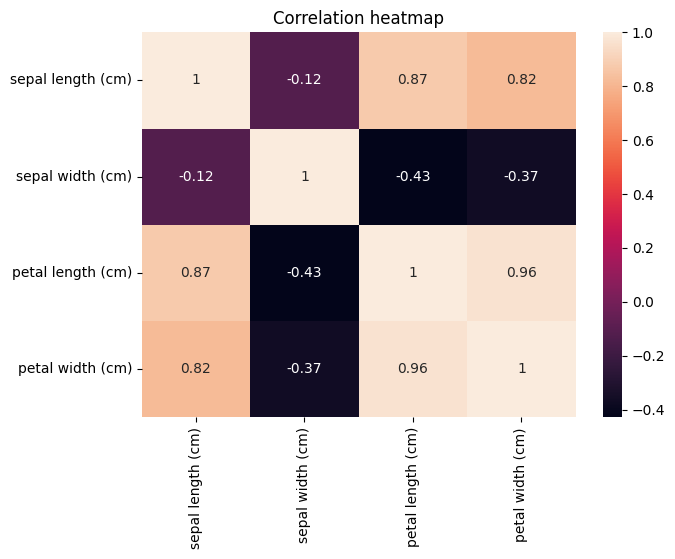

In [400]:
iris_corr = iris_full.drop(columns=['target', 'species_name']).corr(numeric_only=True)

plt.figure(figsize=(7,5))
sns.heatmap(iris_corr, annot=True)
plt.title('Correlation heatmap')
plt.show()

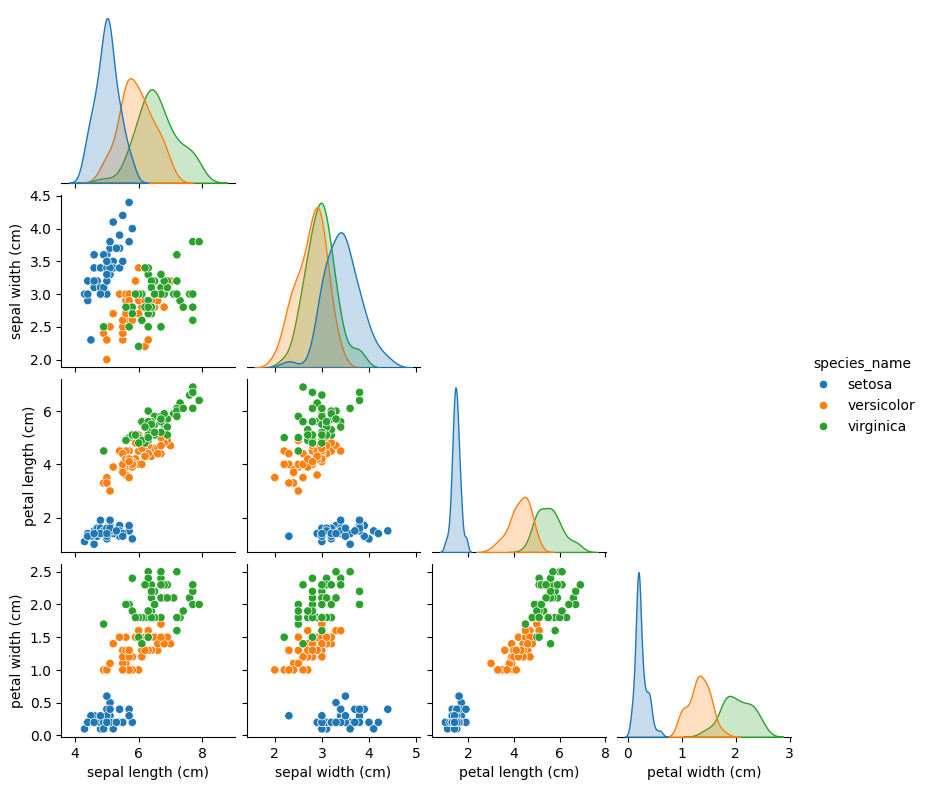

In [401]:
sns.pairplot(iris_full.drop(columns=['target']),
             hue='species_name',
             diag_kind='kde',
             corner=True,
             height=2)
plt.show()

Med pairplot tydliggörs separationen mellan de olika arterna.  
Det är bra separation mellan det mesta, förutom mellan sepal width och sepal length, där det klustras väldigt tight. Tydligast separation i kde finnes i petal width, men även petal length har bra separation.  
Sepal width och length är bytydligt mer klustrat.

In [402]:
iris_full.drop(columns='target').describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


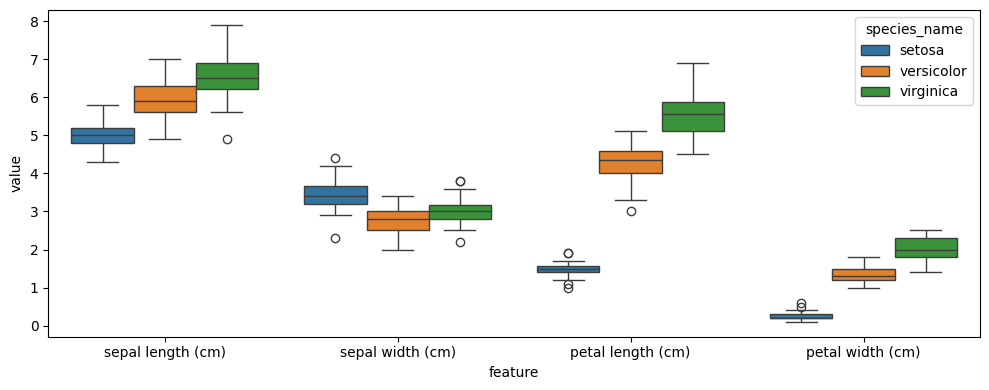

,species_name,feature,value
0,setosa,sepal length (cm),5.1
1,setosa,sepal length (cm),4.9
2,setosa,sepal length (cm),4.7
3,setosa,sepal length (cm),4.6
4,setosa,sepal length (cm),5.0
...,...,...,...
595,virginica,petal width (cm),2.3
596,virginica,petal width (cm),1.9
597,virginica,petal width (cm),2.0
598,virginica,petal width (cm),2.3


In [403]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [col for col in iris_full.columns[:4]]

long_df = iris_full.melt(
    id_vars="species_name",
    value_vars=features,
    var_name="feature",
    value_name="value"
)

plt.figure(figsize=(10, 4))
sns.boxplot(data=long_df, x="feature", y="value", hue="species_name")
plt.tight_layout()
plt.show()
long_df

In [404]:
outlier_idx = set()

for species, grp in iris_full.groupby("species_name"):
    Q1 = grp[features].quantile(0.25)
    Q3 = grp[features].quantile(0.75)
    IQR = Q3 - Q1 # IQR står för InterQuartile Range, alltså allt mellan Q1 och Q3. Mittersta 50 procenten.

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = ((grp[features] < lower) | (grp[features] > upper)).any(axis=1)
    outlier_idx.update(grp.index[mask])

outlier_idx = sorted(outlier_idx)
print(f'Antal outliers: {len(outlier_idx)}')
print(outlier_idx)

iris_clean = iris_full.drop(index=outlier_idx)

iris_clean['species_name'].value_counts()


Antal outliers: 13
[13, 15, 22, 23, 24, 41, 43, 44, 98, 106, 117, 119, 131]


species_name
versicolor    49
virginica     46
setosa        42
Name: count, dtype: int64

In [405]:
print(iris_clean.info())
print(iris_clean.drop(columns='target').describe())

<class 'pandas.DataFrame'>
Index: 137 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  137 non-null    float64
 1   sepal width (cm)   137 non-null    float64
 2   petal length (cm)  137 non-null    float64
 3   petal width (cm)   137 non-null    float64
 4   target             137 non-null    int64  
 5   species_name       137 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.5 KB
None
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         137.000000        137.000000         137.000000   
mean            5.881752          3.040146           3.840146   
std             0.786674          0.404108           1.722450   
min             4.400000          2.000000           1.200000   
25%             5.200000          2.800000           1.600000   
50%             5.800000          3.000000           4.400000   
75%       

## 1. Split and scale data (*)

Do train|test split and scale the data using feature standardization, I used default test size 0.33 and random state 42. Check the mean and standard deviation on training and test data. 

---

In [406]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score


X = iris_clean.drop(columns=['target', 'species_name'])
y = iris_clean['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

X_train.shape, X_test.shape,

((91, 4), (46, 4))

## 2. Classify with logistic regression (*)

Use k-folded cross-validation with logistic regression to find suitable hyperparameters and model. Check the documentation to see which parameters that can be chosen through cross-validation. Check the models parameters and see what it has chosen. 

<details>

<summary>Answer</summary>

weights: 

```py
array([[-1.33033256,  1.35076961, -2.26169407, -2.07715072],
       [ 0.40073538, -0.28598722, -0.58388865, -0.7782766 ],
       [ 0.67977172, -0.81485664,  3.09503329,  3.10542664]])
```

$\ell_1$-ratio:

```py
array([0.2, 0.2, 0.2])
```


<img src = "../assets/pairplot_iris.png" height=300>

Do more EDA than I show here. 

d) Correlation heatmap

<img src = "../assets/Correlation_iris.png" height=300>

The closer the value is to 1 between two features, the more positively linear relationships between them. The closer the value is to -1 the more negatively linear relationships between them. 

e) 

<img src = "../assets/boxplot_iris.png" height=200>

f)
Outlier rows are: [13, 15, 22, 23, 24, 41, 43, 44, 98, 106, 117, 119, 131]

value counts:

|            |   specie_name |
|:-----------|--------------:|
| versicolor |            49 |
| virginica  |            46 |
| setosa     |            42 |

</details>

---

In [407]:


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_pipeline1 = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=10000, random_state=42))
])

scores = cross_val_score(log_pipeline1, X_train, y_train, cv=cv)

print(scores.round(3))
print(f'Mean accuracy for Logistic regression, cv=5: {scores.mean().round(4)}')



[0.947 0.944 1.    1.    0.944]
Mean accuracy for Logistic regression, cv=5: 0.9673


In [408]:
display(log_pipeline1.get_params().keys())

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'scaler', 'logreg', 'scaler__copy', 'scaler__with_mean', 'scaler__with_std', 'logreg__C', 'logreg__class_weight', 'logreg__dual', 'logreg__fit_intercept', 'logreg__intercept_scaling', 'logreg__l1_ratio', 'logreg__max_iter', 'logreg__n_jobs', 'logreg__penalty', 'logreg__random_state', 'logreg__solver', 'logreg__tol', 'logreg__verbose', 'logreg__warm_start'])

In [409]:
log_pipeline2 = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg2', LogisticRegression(C=3,
                                   random_state=42))
])

scores = cross_val_score(log_pipeline2, X_train, y_train, cv=5)
scores.mean().round(4)

np.float64(0.9667)

In [425]:


log_pipeline3 = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg3', LogisticRegression(random_state=42))
])

param_grid = {
    'logreg3__C' : [0.001, 0.01, 0.1, 1, 3, 6, 10, 100],
    'logreg3__solver' : ['lbfgs', 'saga', 'sag', 'newton-cg', 'newton-cholesky'],
    'logreg3__tol' : [0.0001, 0.001, 0.01, 0.1, 1, 5, 10],
}

grid = GridSearchCV(
    estimator=log_pipeline3,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)
score_p2 = cross_val_score(log_pipeline2, X_train, y_train, cv=cv, scoring="accuracy").mean()
score_p3 = grid.best_score_

print(f'P2-score: {score_p2.round(4)}\nP3-score: {score_p3.round(4)}')
print(grid.best_params_)

P2-score: 0.9561
P3-score: 0.9673
{'logreg3__C': 1, 'logreg3__solver': 'lbfgs', 'logreg3__tol': 0.0001}


In [411]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg3', LogisticRegression(
        random_state=42,
        C= 1,
        solver='lbfgs',
        tol= 0.0001
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

### Kommentar kring modellerna

I modell 2 ökar till synes prestandan till 0.9889 från 0.9778 i modell 1. I tredje modellen provade jag en annan strategi där jag lät GridSearchCV räkna ut de bästa parametrarna utifrån de jag skrivit in i param_grid,

## 3. Evaluate model (*)

Make a prediction on the testing data. 

&nbsp; a) Check manually the first 10 values of $y_{test}$ against your prediction. 

&nbsp; b) Plot a confusion matrix. Can you see which predictions the model have mispredicted?

&nbsp; c) Print a classification report 

<details>

<summary>Answer</summary>


b) 

<img src = "../assets/confusion_matrix_iris.png" height=300>



c) 

Classification report 

```py
          precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.94      0.97        16
           2       0.94      1.00      0.97        16

    accuracy                           0.98        46
   macro avg       0.98      0.98      0.98        46
weighted avg       0.98      0.98      0.98        46
```






</details>

---

### a)

In [412]:


best_model = grid.best_estimator_

log_pipeline2.fit(X_train, y_train)
y_pred2 = log_pipeline2.predict(X_test)
y_pred3 = best_model.predict(X_test)

comparison2 = pd.DataFrame({
    'Actual': y_test.iloc[:10],
    'Predicted': y_pred2[:10]
})
comparison3 = pd.DataFrame({
    'Actual': y_test.iloc[:10],
    'Predicted': y_pred3[:10]
})

print(comparison2)
print(comparison3)

     Actual  Predicted
147       2          2
69        1          1
46        0          0
127       2          2
27        0          0
77        1          2
39        0          0
45        0          0
109       2          2
95        1          1
     Actual  Predicted
147       2          2
69        1          1
46        0          0
127       2          2
27        0          0
77        1          2
39        0          0
45        0          0
109       2          2
95        1          1


### b)

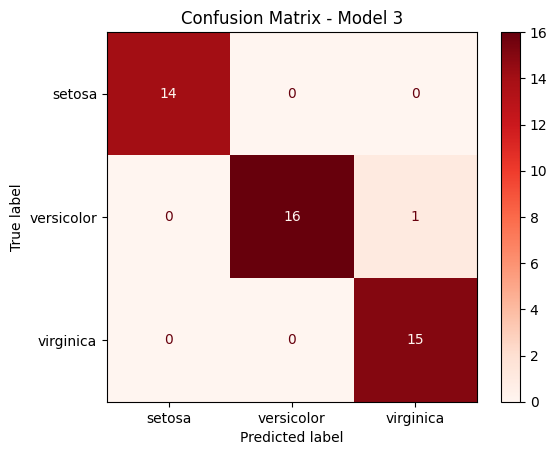

 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.94      0.97        17
           2       0.94      1.00      0.97        15

    accuracy                           0.98        46
   macro avg       0.98      0.98      0.98        46
weighted avg       0.98      0.98      0.98        46



In [413]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred2,
    cmap='Reds',
    display_labels=iris.target_names
)
plt.title('Confusion Matrix - Model 3')
plt.show()

print(f' Classification Report:\n {classification_report(y_test, y_pred2)}')

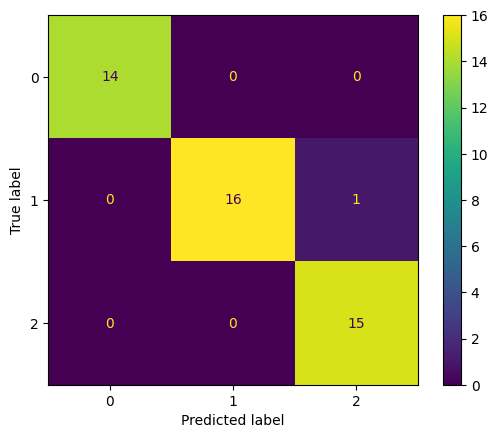

In [414]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred3
)

---

## Test med k-NN

In [415]:


knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=3))
])

knn_param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2] #Manhattan eller Euclidean (1 eller 2)
}

knn_grid = GridSearchCV(
    estimator = knn_pipeline,
    param_grid= knn_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

print('KNN best params', knn_grid.best_params_)
print('KNN best CV score', knn_grid.best_score_)


KNN best params {'knn__n_neighbors': 7, 'knn__p': 1, 'knn__weights': 'uniform'}
KNN best CV score 0.9666666666666668


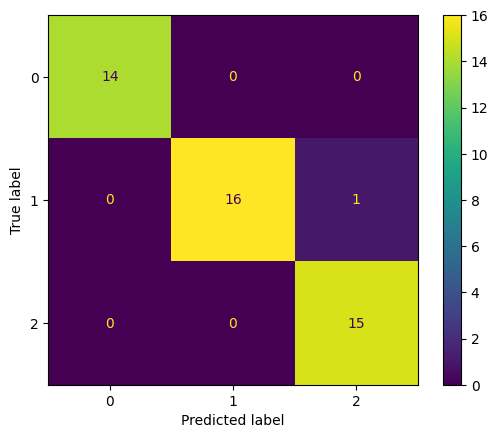

In [416]:
knn_pred = knn_grid.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred=knn_pred)

## 4. $k$-folded cross-validation for evaluation (**)

To be more robust in reporting the results, you should report the results as $\mu_{score}$, i.e. average score through a k-folded cross-validation. Report the score for precision, recall, f1-score for each label and overall accuracy. Do the cross-validation manually using for statement. 

In [421]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import numpy as np

def cv_metrics(estimator, X, y, n_splits=5, random_state=42):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    labels = np.sort(np.unique(y))

    precisions, recalls, f1s, accs = [], [], [], []

    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = clone(estimator)      # ny modell per fold
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        p, r, f1, _ = precision_recall_fscore_support(
            y_val, y_pred, labels=labels, average=None, zero_division=0
        )
        precisions.append(p)
        recalls.append(r)
        f1s.append(f1)
        accs.append(accuracy_score(y_val, y_pred))

    summary = pd.DataFrame({
        "label": labels,
        "precision_mean": np.mean(precisions, axis=0),
        "precision_std": np.std(precisions, axis=0),
        "recall_mean": np.mean(recalls, axis=0),
        "recall_std": np.std(recalls, axis=0),
        "f1_mean": np.mean(f1s, axis=0),
        "f1_std": np.std(f1s, axis=0),
    })

    accuracy = {
        "accuracy_mean": float(np.mean(accs)),
        "accuracy_std": float(np.std(accs))
    }

    return summary, accuracy

label_scores, acc_scores = cv_metrics(model, X_train, y_train, n_splits=5, random_state=42)

print(label_scores.round(4))
print(acc_scores)

   label  precision_mean  precision_std  recall_mean  recall_std  f1_mean  \
0      0          1.0000         0.0000       1.0000      0.0000   1.0000   
1      1          0.9464         0.0659       0.9667      0.0667   0.9531   
2      2          0.9714         0.0571       0.9381      0.0762   0.9510   

   f1_std  
0  0.0000  
1  0.0391  
2  0.0403  
{'accuracy_mean': 0.967251461988304, 'accuracy_std': 0.02676037704946797}


---

Kokchun Giang

[LinkedIn][linkedIn_kokchun]

[GitHub portfolio][github_portfolio]

[linkedIn_kokchun]: https://www.linkedin.com/in/kokchungiang/
[github_portfolio]: https://github.com/kokchun/Portfolio-Kokchun-Giang

---

### Testing

logreg best CV: 0.9673 params: {'clf__C': 1, 'clf__solver': 'lbfgs', 'clf__tol': 0.0001}
knn best CV: 0.9667 params: {'clf__n_neighbors': 7, 'clf__p': 1, 'clf__weights': 'uniform'}
Selected model: logreg
Test accuracy: 0.9783
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.94      0.97        17
           2       0.94      1.00      0.97        15

    accuracy                           0.98        46
   macro avg       0.98      0.98      0.98        46
weighted avg       0.98      0.98      0.98        46



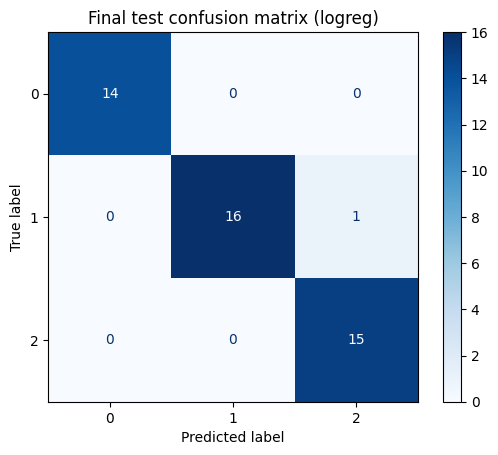

In [418]:
searches = {
    "logreg": GridSearchCV(
        Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(random_state=42, max_iter=10000))]),
        param_grid={"clf__C":[0.1, 1, 3, 10], "clf__solver":["lbfgs","newton-cg","newton-cholesky"], "clf__tol":[1e-4,1e-3,1e-2]},
        cv=cv, scoring="accuracy", n_jobs=-1
    ),
    "knn": GridSearchCV(
        Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
        param_grid={"clf__n_neighbors":[3,5,7,9,11,15], "clf__weights":["uniform","distance"], "clf__p":[1,2]},
        cv=cv, scoring="accuracy", n_jobs=8
    )
}

for name, gs in searches.items():
    gs.fit(X_train, y_train)
    print(name, "best CV:", round(gs.best_score_, 4), "params:", gs.best_params_)

# 3) Välj vinnare på CV-score
best_name, best_search = max(searches.items(), key=lambda kv: kv[1].best_score_)
best_model = best_search.best_estimator_
print("Selected model:", best_name)

# 4) Nu först: EN enda testutvärdering
y_test_pred = best_model.predict(X_test)
print("Test accuracy:", round(accuracy_score(y_test, y_test_pred), 4))
print(classification_report(y_test, y_test_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, cmap="Blues")
plt.title(f"Final test confusion matrix ({best_name})")
plt.show()